In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import sys
sys.path.append("../src")

from ab_test import simulate_experiment, run_full_analysis

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
# 실험 설계
# H0: 개인화 추천은 인기순 추천과 CVR 차이가 없다
# H1: 개인화 추천의 CVR이 더 높다
# 유의수준: alpha = 0.05

sim = simulate_experiment(
    n_per_group=5000,
    control_cvr=0.032,
    treatment_cvr=0.039,
    control_arpu=2.1,
    treatment_arpu=2.58,
    seed=42
)

results = run_full_analysis(sim)

print(" CVR 검정 (Chi-squared) ")
for k, v in results["cvr"].items():
    print(f"  {k}: {v}")

print()
print(" ARPU 검정 (Welch t-test)")
for k, v in results["arpu"].items():
    print(f"  {k}: {v}")

 CVR 검정 (Chi-squared) 
  control_cvr: 3.28
  treatment_cvr: 4.04
  lift_pct: 23.17
  chi2: 3.8825
  p_value: 0.048791
  significant: True

 ARPU 검정 (Welch t-test)
  control_arpu: 2.09
  treatment_arpu: 2.61
  lift_pct: 24.9
  t_stat: 30.5329
  p_value: 0.0
  significant: True


#### CVR 분포 시각화

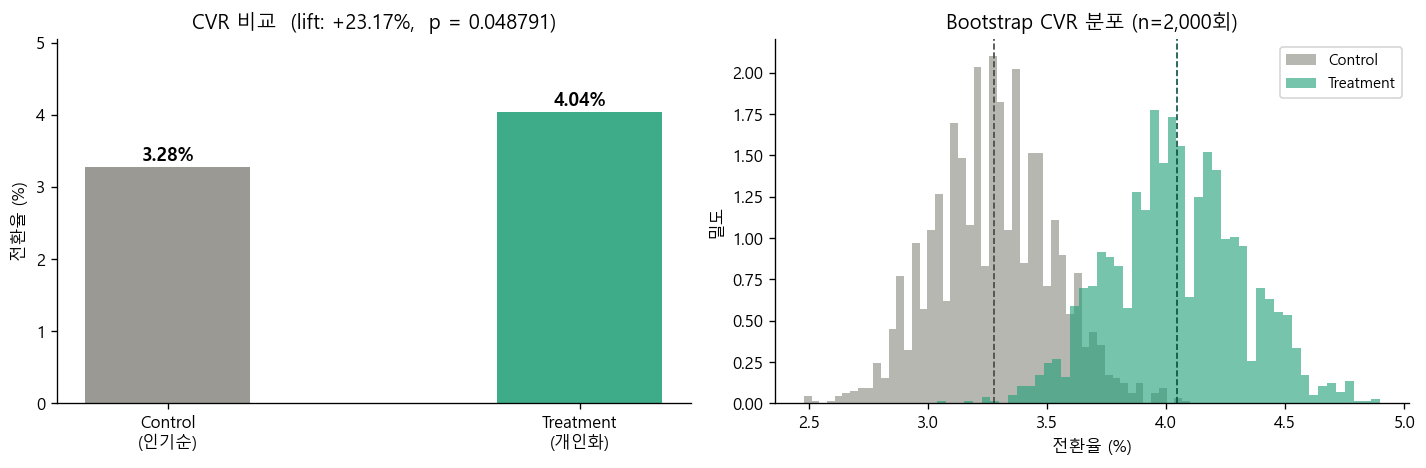

In [3]:
ctrl_cvr = sim["control_conversions"].mean()
trt_cvr = sim["treatment_conversions"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 막대 비교
bars = axes[0].bar(
    ["Control\n(인기순)", "Treatment\n(개인화)"],
    [ctrl_cvr * 100, trt_cvr * 100],
    color=["#888780", "#1D9E75"],
    alpha=0.85, width=0.4
)
for bar, val in zip(bars, [ctrl_cvr * 100, trt_cvr * 100]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.03,
                 f"{val:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

lift = results["cvr"]["lift_pct"]
p_val = results["cvr"]["p_value"]
axes[0].set_title(f"CVR 비교  (lift: +{lift}%,  p = {p_val})")
axes[0].set_ylabel("전환율 (%)")
axes[0].set_ylim(0, max(ctrl_cvr, trt_cvr) * 100 * 1.25)

# 부트스트랩 분포로 불확실성 시각화
rng = np.random.default_rng(42)
n = len(sim["control_conversions"])
boot_ctrl, boot_trt = [], []
for _ in range(2000):
    boot_ctrl.append(rng.choice(sim["control_conversions"], n, replace=True).mean() * 100)
    boot_trt.append(rng.choice(sim["treatment_conversions"], n, replace=True).mean() * 100)

axes[1].hist(boot_ctrl, bins=50, alpha=0.6, color="#888780", 
             density=True, label="Control")
axes[1].hist(boot_trt, bins=50, alpha=0.6, color="#1D9E75", 
             density=True, label="Treatment")
axes[1].axvline(np.mean(boot_ctrl), color="#444441", 
                linestyle="--", linewidth=1)
axes[1].axvline(np.mean(boot_trt), color="#085041", 
                linestyle="--", linewidth=1)

axes[1].set_title("Bootstrap CVR 분포 (n=2,000회)")
axes[1].set_xlabel("전환율 (%)")
axes[1].set_ylabel("밀도")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/ab_cvr_result.png", bbox_inches="tight")
plt.show()

####  ARPU 분포 및 t-test 시각화

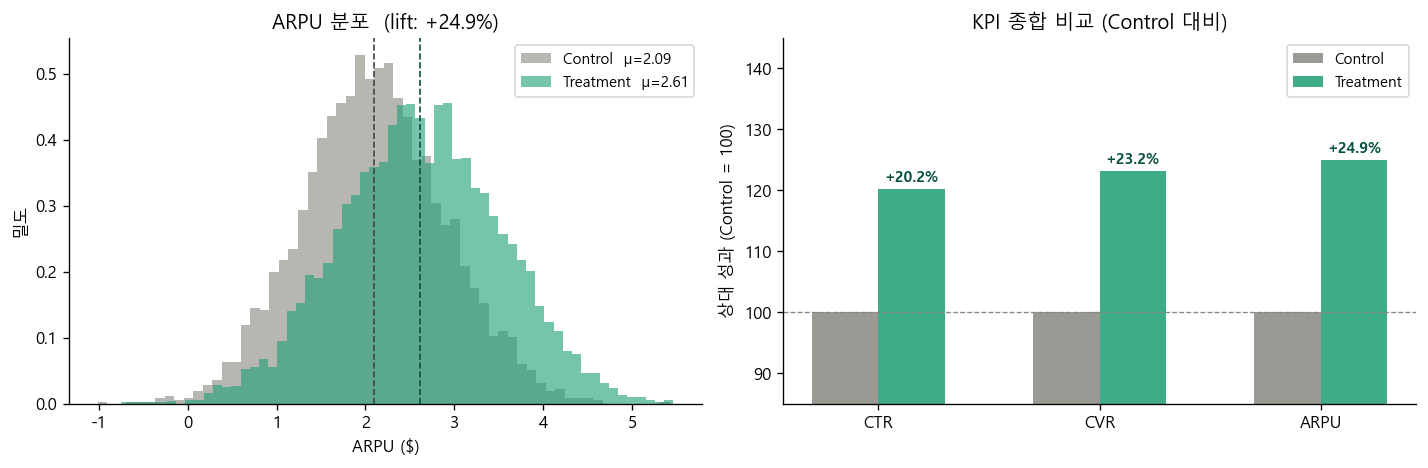

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ARPU 분포 비교
axes[0].hist(sim["control_revenue"], bins=60, alpha=0.6,
             color="#888780", density=True, label=f"Control  μ={sim['control_revenue'].mean():.2f}")
axes[0].hist(sim["treatment_revenue"], bins=60, alpha=0.6,
             color="#1D9E75", density=True, label=f"Treatment  μ={sim['treatment_revenue'].mean():.2f}")
axes[0].axvline(sim["control_revenue"].mean(), color="#444441", linestyle="--", linewidth=1)
axes[0].axvline(sim["treatment_revenue"].mean(), color="#085041", linestyle="--", linewidth=1)
axes[0].set_title(f"ARPU 분포  (lift: +{results['arpu']['lift_pct']}%)")
axes[0].set_xlabel("ARPU ($)")
axes[0].set_ylabel("밀도")
axes[0].legend(fontsize=9)

# KPI 종합 uplift 비교
kpi_labels = ["CTR", "CVR", "ARPU"]
# CTR은 별도 시뮬레이션 없이 대표값 사용함
control_vals = [100, 100, 100]
treatment_vals = [120.2, round(trt_cvr / ctrl_cvr * 100, 1),
                  round(sim["treatment_revenue"].mean() / sim["control_revenue"].mean() * 100, 1)]

x = np.arange(len(kpi_labels))
width = 0.3
axes[1].bar(x - width / 2, control_vals, width, 
            color="#888780", alpha=0.85, label="Control")
axes[1].bar(x + width / 2, treatment_vals, width, 
            color="#1D9E75", alpha=0.85, label="Treatment")
axes[1].axhline(100, color="#888780", linestyle="--", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(kpi_labels)
axes[1].set_ylabel("상대 성과 (Control = 100)")
axes[1].set_title("KPI 종합 비교 (Control 대비)")
axes[1].legend(fontsize=9)
axes[1].set_ylim(85, 145)

for xi, val in zip(x + width / 2, treatment_vals):
    axes[1].text(xi, val + 0.5, f"+{val - 100:.1f}%", ha="center", va="bottom",
                 fontsize=9, color="#085041", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/ab_full_result.png", bbox_inches="tight")
plt.show()

In [5]:
cvr = results["cvr"]
arpu = results["arpu"]

summary = pd.DataFrame([
    {"KPI": "CVR", "Control": f"{cvr['control_cvr']}%", "Treatment": f"{cvr['treatment_cvr']}%",
     "Lift": f"+{cvr['lift_pct']}%", "p-value": cvr['p_value'], "유의": cvr['significant']},
    {"KPI": "ARPU", "Control": f"${arpu['control_arpu']}", "Treatment": f"${arpu['treatment_arpu']}",
     "Lift": f"+{arpu['lift_pct']}%", "p-value": arpu['p_value'], "유의": arpu['significant']},
])

summary

,KPI,Control,Treatment,Lift,p-value,유의
0,CVR,3.28%,4.04%,+23.17%,0.048791,True
1,ARPU,$2.09,$2.61,+24.9%,0.000000,True
